In [ ]:
# Step 01: Import Libraries

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.13.0+cpu


In [2]:
# Step 02: Preparing the data

In [3]:
df = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])

# Using Store 1, Item 1 for the LSTM
subset = df[(df['store'] == 1) & (df['item'] == 1)].sort_values('date')
values = subset['sales'].values.astype(float)

print(f"Total data points: {len(values)}")
print(f"Min: {values.min():.0f}, Max: {values.max():.0f}, Mean: {values.mean():.1f}")

# Scaling the data to [0, 1] as neural networks need normalized input
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values.reshape(-1, 1))

print(f"After scaling — Min: {scaled.min():.3f}, Max: {scaled.max():.3f}")

Total data points: 1826
Min: 4, Max: 50, Mean: 20.0
After scaling — Min: 0.000, Max: 1.000


In [4]:
# Step 03: Creating Sliding Window dataset

In [6]:
SEQ_LEN  = 90   # Input: last 90 days
PRED_LEN = 30   # Output: next 30 days

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.X = []
        self.y = []
        for i in range(len(data) - seq_len - pred_len + 1):
            self.X.append(data[i : i + seq_len])
            self.y.append(data[i + seq_len : i + seq_len + pred_len])
        self.X = torch.FloatTensor(np.array(self.X))
        self.y = torch.FloatTensor(np.array(self.y))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Splitting the data as 85% training data and 15% testing 
train_size = int(len(scaled) * 0.85)
train_data = scaled[:train_size]
test_data  = scaled[train_size - SEQ_LEN:]   # Overlap needed for sequences

train_dataset = TimeSeriesDataset(train_data, SEQ_LEN, PRED_LEN)
test_dataset  = TimeSeriesDataset(test_data,  SEQ_LEN, PRED_LEN)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches:     {len(test_loader)}")
print(f"Input shape of one sample: {train_dataset.X[0].shape}")
print(f"Output shape of one sample: {train_dataset.y[0].shape}")

Training batches: 45
Test batches:     8
Input shape of one sample: torch.Size([90, 1])
Output shape of one sample: torch.Size([30, 1])


In [7]:
# Step 04: Defining the LSTM architecture

In [9]:
class SalesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=30, dropout=0.2):
        super(SalesLSTM, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(64, output_size)
    
    def forward(self, x):
        lstm_out, _  = self.lstm(x)
        last_step = lstm_out[:, -1, :]   
        out = self.dropout(last_step)
        out = self.relu(self.fc1(out))
        out = self.fc_out(out)
        return out

model_lstm = SalesLSTM().to(DEVICE)

total_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f"Model architecture:\n{model_lstm}")
print(f"\nTotal trainable parameters: {total_params:,}")

Model architecture:
SalesLSTM(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc_out): Linear(in_features=64, out_features=30, bias=True)
)

Total trainable parameters: 209,374


In [10]:
# Step 05: Training the LSTM

In [12]:
EPOCHS    = 80
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

train_losses = []
val_losses   = []
best_val_loss = float('inf')

print("Starting training...")
for epoch in range(EPOCHS):
    # Training phase
    model_lstm.train()
    batch_losses = []
    for X_b, y_b in train_loader:
        X_b = X_b.to(DEVICE)
        y_b = y_b.squeeze(-1).to(DEVICE)
        
        optimizer.zero_grad()
        pred = model_lstm(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    
    avg_train_loss = np.mean(batch_losses)
    
    # Validation phase
    model_lstm.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b = X_b.to(DEVICE)
            y_b = y_b.squeeze(-1).to(DEVICE)
            pred = model_lstm(X_b)
            loss = criterion(pred, y_b)
            val_batch_losses.append(loss.item())
    
    avg_val_loss = np.mean(val_batch_losses)
    scheduler.step(avg_val_loss)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model_lstm.state_dict(), '../models/lstm_best.pt')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

print(f"\nTraining complete! Best Val Loss: {best_val_loss:.6f}")

Starting training...
Epoch  10/80 | Train Loss: 0.015689 | Val Loss: 0.020041
Epoch  20/80 | Train Loss: 0.015140 | Val Loss: 0.020182
Epoch  30/80 | Train Loss: 0.015107 | Val Loss: 0.019990
Epoch  40/80 | Train Loss: 0.014962 | Val Loss: 0.020428
Epoch  50/80 | Train Loss: 0.014986 | Val Loss: 0.020200
Epoch  60/80 | Train Loss: 0.014877 | Val Loss: 0.020366
Epoch  70/80 | Train Loss: 0.014818 | Val Loss: 0.020240
Epoch  80/80 | Train Loss: 0.014853 | Val Loss: 0.020145

Training complete! Best Val Loss: 0.019895


In [13]:
# Step 06: Plotting the training curve

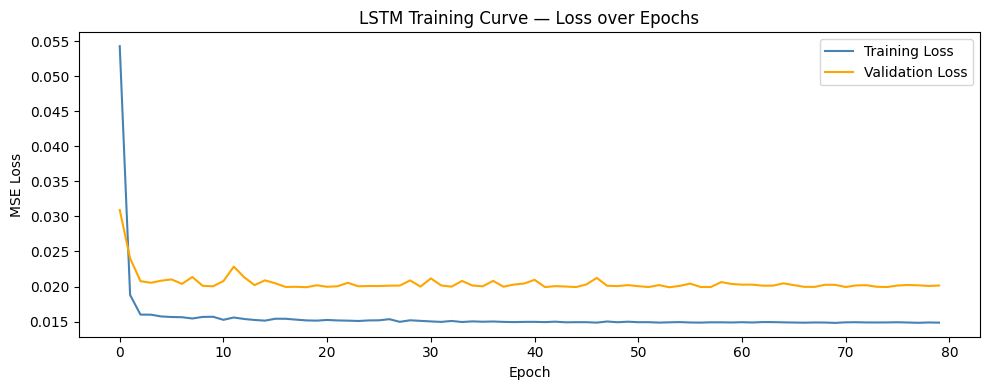

If validation loss curves smoothly downward, the model is learning well.
If val loss goes up while train loss goes down, that's overfitting.


In [14]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss', color='steelblue')
plt.plot(val_losses,   label='Validation Loss', color='orange')
plt.title('LSTM Training Curve — Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('../results/lstm_training_curve.png', dpi=150)
plt.show()
print("If validation loss curves smoothly downward, the model is learning well.")
print("If val loss goes up while train loss goes down, that's overfitting.")

In [15]:
# Step 07: Generating predictions and evaluate

In [18]:
model_lstm.load_state_dict(torch.load('../models/lstm_best.pt', map_location=DEVICE))
model_lstm.eval()

all_preds = []
all_actuals = []

with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b  = X_b.to(DEVICE)
        pred = model_lstm(X_b).cpu().numpy()
        all_preds.append(pred)
        all_actuals.append(y_b.squeeze(-1).numpy())

preds = np.vstack(all_preds).flatten()
actuals = np.vstack(all_actuals).flatten()

# Converting back to original scale
preds = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
actuals = scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()
preds = np.maximum(preds, 0)

mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape = (abs(actuals - preds) / (actuals + 1e-5)).mean() * 100

print("LSTM MODEL RESULTS — Store 1, Item 1")
print(f" MAE:  {mae:.2f} units")
print(f" RMSE: {rmse:.2f} units")
print(f" MAPE: {mape:.2f}%")

LSTM MODEL RESULTS — Store 1, Item 1
 MAE:  5.09 units
 RMSE: 6.44 units
 MAPE: 23.94%
